<a href="https://colab.research.google.com/github/Dentriciche/Project_SP/blob/main/03%20-%20Model%20Building/transformer_distilbert_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DistilBERT Fine-tuning for South Park Character Classification

This notebook fine-tunes a pre-trained DistilBERT model for predicting which South Park character spoke a given line of dialogue.

## Why DistilBERT?

DistilBERT is a distilled version of BERT that offers an excellent balance between performance and efficiency:

- **97% of BERT's performance** on downstream tasks
- **Pre-trained on massive corpus** - Understands language nuances
- **Transfer learning** - Leverages knowledge from billions of tokens

### Transfer Learning Benefits:

1. **Better generalization** - Pre-trained on diverse text
2. **Faster convergence** - Starts with good language understanding
3. **Better handling of rare words** - Seen more vocabulary during pre-training
4. **Robust representations** - Learned from 16GB+ of text data

For character classification, DistilBERT should capture:
- **Character-specific vocabulary** - Cartman's phrases, Stan's expressions
- **Syntactic patterns** - How different characters structure sentences
- **Contextual nuances** - Subtle differences in word usage

## 1. Imports and Setup

In [32]:
# from google.colab import drive
# drive.mount('/content/drive',  force_remount=True)

# import os
# os.chdir('/content/drive/MyDrive/Project_SP')

In [33]:
# Hugging Face transformers
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Data processing
import pandas as pd
import numpy as np

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA H100 80GB HBM3
GPU Memory: 85.02 GB


## 2. Configuration Parameters

In [34]:
# Dataset configuration
K = 31

# Model configuration
MODEL_NAME = 'distilbert-base-uncased'
MAX_SEQ_LEN = 256

# Training hyperparameters (optimized for fine-tuning pre-trained models)
BATCH_SIZE = 64
LEARNING_RATE = 4e-5  # Lower LR for fine-tuning (typical: 2e-5 to 5e-5)
NUM_EPOCHS = 50
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1  # 10% of training for warmup

# Early stopping
EARLY_STOP_PATIENCE = 7


print(f"Configuration:")
print(f"  Top K characters: {K}")
print(f"  Model: {MODEL_NAME}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Warmup ratio: {WARMUP_RATIO}")
print(f"  Early stopping patience: {EARLY_STOP_PATIENCE}")

Configuration:
  Top K characters: 31
  Model: distilbert-base-uncased
  Max sequence length: 256
  Batch size: 64
  Learning rate: 4e-05
  Max epochs: 50
  Weight decay: 0.01
  Warmup ratio: 0.1
  Early stopping patience: 7


## 3. Load Data

In [35]:
import pandas as pd
# read data from parquet 
train_data = pd.read_parquet('01 - Inputs/train_data_labels_as_numbers.parquet')
val_data = pd.read_parquet('01 - Inputs/val_data_labels_as_numbers.parquet')
test_data = pd.read_parquet('01 - Inputs/test_data_labels_as_numbers.parquet')

## 6. Text Preprocessing with DistilBERT Tokenizer

Unlike custom transformers, we use Hugging Face's pre-trained tokenizer:

- **Pre-trained vocabulary** - 30,522 WordPiece tokens 
- **Automatic special tokens** - [CLS], [SEP], [PAD] handled automatically
- **Subword tokenization** - Handles out-of-vocabulary words better
- **Case handling** - 'uncased' model lowercases automatically

The tokenizer will:
1. Add [CLS] token at the beginning
2. Add [SEP] token at the end
3. Pad sequences to max_length
4. Create attention masks (1 for real tokens, 0 for padding)

In [36]:
train_texts = train_data['Line'].tolist()
train_labels = train_data['Character'].tolist()

val_texts = val_data['Line'].tolist()
val_labels = val_data['Character'].tolist()

test_texts = test_data['Line'].tolist()
test_labels = test_data['Character'].tolist()

In [37]:
# Load pre-trained DistilBERT tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

print(f"\nTokenizer info:")
print(f"  Vocabulary size: {len(tokenizer):,}")
print(f"  Model max length: {tokenizer.model_max_length}")
print(f"  Special tokens: {tokenizer.special_tokens_map}")

# Test tokenization on a sample
sample_text = train_texts[0]
print(f"\nSample text: '{sample_text}'")

# Tokenize
encoded = tokenizer(
    sample_text,
    max_length=MAX_SEQ_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print(f"\nTokenized output:")
print(f"  Input IDs shape: {encoded['input_ids'].shape}")
print(f"  Attention mask shape: {encoded['attention_mask'].shape}")
print(f"  First 20 tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0][:20])}")
print(f"  First 20 IDs: {encoded['input_ids'][0][:20].tolist()}")
print(f"  First 20 mask: {encoded['attention_mask'][0][:20].tolist()}")

Loading tokenizer: distilbert-base-uncased

Tokenizer info:
  Vocabulary size: 30,522
  Model max length: 512
  Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

Sample text: 'Ma'am, we are a very important talent agency. If your producers knew you were forcing people of our stature to the back of the line, well-'

Tokenized output:
  Input IDs shape: torch.Size([1, 256])
  Attention mask shape: torch.Size([1, 256])
  First 20 tokens: ['[CLS]', 'ma', "'", 'am', ',', 'we', 'are', 'a', 'very', 'important', 'talent', 'agency', '.', 'if', 'your', 'producers', 'knew', 'you', 'were', 'forcing']
  First 20 IDs: [101, 5003, 1005, 2572, 1010, 2057, 2024, 1037, 2200, 2590, 5848, 4034, 1012, 2065, 2115, 6443, 2354, 2017, 2020, 6932]
  First 20 mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## 7. Dataset and DataLoader
Create PyTorch Dataset compatible with Hugging Face transformers.

In [38]:
class DistilBertDataset(Dataset):
    """Dataset for South Park dialogue classification with DistilBERT."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenize with DistilBERT tokenizer
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),  # Remove batch dimension
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


# Create datasets
train_dataset = DistilBertDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LEN)
val_dataset = DistilBertDataset(val_texts, val_labels, tokenizer, MAX_SEQ_LEN)
test_dataset = DistilBertDataset(test_texts, test_labels, tokenizer, MAX_SEQ_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Datasets created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test a batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  input_ids: {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")
print(f"  labels: {sample_batch['labels'].shape}")

Datasets created:
  Train batches: 441
  Val batches: 95
  Test batches: 95

Sample batch shapes:
  input_ids: torch.Size([64, 256])
  attention_mask: torch.Size([64, 256])
  labels: torch.Size([64])


## 8. Load Pre-trained DistilBERT Model
We load DistilBERT with a classification head for K=31 classes.

### DistilBERT Architecture:

1. **Embedding Layer** - WordPiece embeddings (30,522 vocab)
2. **6 Transformer Layers** - Multi-head self-attention + FFN (vs 12 in BERT)
3. **Hidden Size** - 768 dimensions 
4. **Attention Heads** - 12 heads per layer
5. **Classification Head** - Linear layer (768 → K classes)
### Key Differences from BERT:
- **No token-type embeddings** - Removed for efficiency
- **No pooler layer** - Uses [CLS] token directly
- **Fewer layers** - 6 instead of 12 (40% reduction)
### Pre-training:
DistilBERT was trained using knowledge distillation from BERT-base on:
- English Wikipedia (2.5B words)
- BookCorpus (800M words)
Total: ~16GB of text data

In [39]:
# Load pre-trained DistilBERT with classification head
print(f"Loading pre-trained model: {MODEL_NAME}")
print(f"This may take a minute on first run (downloading ~250MB)...\n")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=K,  # Number of output classes
    output_attentions=False,
    output_hidden_states=False
)

model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
classifier_params = sum(p.numel() for p in model.classifier.parameters())

print(f"Model loaded successfully!")
print(f"\nModel statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Classifier head parameters: {classifier_params:,}")
print(f"  Pre-trained parameters: {total_params - classifier_params:,}")
print(f"\nModel architecture:")
print(model)

# Verify model is on correct device
print(f"\nModel device: {next(model.parameters()).device}")

Loading pre-trained model: distilbert-base-uncased
This may take a minute on first run (downloading ~250MB)...



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!

Model statistics:
  Total parameters: 66,977,311
  Trainable parameters: 66,977,311
  Classifier head parameters: 23,839
  Pre-trained parameters: 66,953,472

Model architecture:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (d

## 9. Class Weights

In [40]:
import pickle
label_to_char = pickle.load(open('01 - Inputs/label_to_char.pkl', 'rb'))
char_to_label = pickle.load(open('01 - Inputs/char_to_label.pkl', 'rb'))

In [41]:
# Compute balanced class weights
class_weights = compute_class_weight('balanced', classes=np.arange(K), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights computed")
print(f"Class weights: {class_weights}")
print(f"\nWeight range: {class_weights.min():.3f} - {class_weights.max():.3f}")
print(f"\nCharacter weights:")
for idx, weight in enumerate(class_weights):
    print(f"  {label_to_char[idx]}: {weight:.3f}")

Class weights computed
Class weights: tensor([0.1364, 0.1860, 0.1983, 0.5028, 0.5031, 1.2196, 1.4968, 1.5143, 1.7273,
        1.9168, 2.0236, 2.0372, 2.2490, 2.3119, 2.3661, 2.3723, 3.1880, 3.4945,
        3.7390, 4.2064, 4.2260, 4.3061, 4.4979, 4.6356, 4.6594, 4.6834, 5.0198,
        5.4082, 5.9384, 6.1391, 6.2232], device='cuda:0')

Weight range: 0.136 - 6.223

Character weights:
  Cartman: 0.136
  Stan: 0.186
  Kyle: 0.198
  Butters: 0.503
  Randy: 0.503
  Mr. Garrison: 1.220
  Sharon: 1.497
  Chef: 1.514
  Kenny: 1.727
  Jimmy: 1.917
  Mr. Mackey: 2.024
  Gerald: 2.037
  Liane: 2.249
  Wendy: 2.312
  Jimbo: 2.366
  Sheila: 2.372
  Announcer: 3.188
  Stephen: 3.495
  Craig: 3.739
  Jesus: 4.206
  Clyde: 4.226
  Principal Victoria: 4.306
  Linda: 4.498
  Token: 4.636
  Mrs. Garrison: 4.659
  Terrance: 4.683
  Tweek: 5.020
  Mayor: 5.408
  Phillip: 5.938
  Bebe: 6.139
  Man: 6.223


## 10. Training Function with Early Stopping

Fine-tuning best practices for pre-trained transformers:

### Optimizer:
- **AdamW**
- Adam with decoupled weight decay (better for transformers)
- **Low learning rate**
- 2e-5 (typical range: 2e-5 to 5e-5)
- **Weight decay**
- 0.01 for regularization
### Learning Rate Schedule:
- **Linear warmup**
- Gradually increase LR for first 10% of training
- **Linear decay** - Gradually decrease LR to 0 after warmup
- **Why?** Prevents catastrophic forgetting of pre-trained weights
### Other Techniques:
- **Gradient clipping**
    - Prevents exploding gradients (max_norm=1.0)
- **Early stopping**
    - Stops when validation loss plateaus
- **Class weights**
    - Handles imbalanced character distribution

In [42]:
def train_distilbert(model, train_loader, val_loader, num_epochs, criterion, optimizer, warmup_ratio, patience=10, scheduler=None):
    """
    Fine-tune DistilBERT model with best practices.

    Args:
        model: DistilBERT model
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Maximum number of epochs
        lr: Learning rate
        weight_decay: L2 regularization strength
        class_weights: Class weights for imbalanced data
        warmup_ratio: Ratio of training for warmup
        patience: Early stopping patience

    Returns:
        Dictionary with model, history, and metrics
    """
    model.to(device)

    

    # Calculate total training steps
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)

    # Linear warmup + decay scheduler
    if scheduler is None:
        scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    print(f"Training setup:")
    print(f"  Total steps: {total_steps:,}")
    print(f"  Warmup steps: {warmup_steps:,} ({warmup_ratio*100:.0f}%)")
    print(f"  Steps per epoch: {len(train_loader):,}")

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': [], 'val_f1': []}
    best_val_loss = float('inf')
    best_val_f1 = 0.0
    best_model_state = None
    patience_counter = 0

    print("\nFine-tuning DistilBERT...")
    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds, train_labels_list = [], []

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in train_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            loss = criterion(logits, labels)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()  # Update learning rate

            # Track metrics
            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_list.extend(labels.cpu().numpy())

            # Update progress bar
            current_lr = scheduler.get_last_lr()[0]
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})

        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels_list, train_preds)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds, val_labels_list = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                logits = outputs.logits
                loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)
        val_f1 = f1_score(val_labels_list, val_preds, average='macro')

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(scheduler.get_last_lr()[0])
        history['val_f1'].append(val_f1)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f} Val Acc={val_acc:.4f} | LR={scheduler.get_last_lr()[0]:.2e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  -> New best model (val_loss: {val_loss:.4f})")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load best model
    model.load_state_dict(best_model_state)
    elapsed = time.time() - start_time
    print(f"\nFine-tuning completed in {elapsed/60:.2f} minutes")

    return {'model': model, 'history': history, 'best_val_loss': best_val_loss, 'time': elapsed}

## 11. Train Model

In [43]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/Project_SP/utils')
sys.path.insert(0, '/content/drive/MyDrive/Project_SP/03 - Model Building')

In [44]:
from focal_loss import FocalLoss
import copy

loss_types = ['cross_entropy_label_smoothing', 'cross_entropy', 'focal_loss']
components = {}
full_models = {}

# Calculate scheduler parameters 
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

print(f"Scheduler setup:")
print(f"  Total steps: {total_steps:,}")
print(f"  Warmup steps: {warmup_steps:,}")
print(f"  Steps per epoch: {len(train_loader):,}")

# Create separate model, optimizer, and scheduler for each loss type
for loss_type in loss_types:
    print(f"\nSetting up {loss_type}...")
    
    # 1. Fresh model for this loss type
    full_models[loss_type] = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=K,
        output_attentions=False,
        output_hidden_states=False
    ).to(device)
    
    # 2. optimizer for this model's parameters
    optimizer = optim.AdamW(
        full_models[loss_type].parameters(),  
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    # 3. criterion based on loss type
    if loss_type == 'cross_entropy_label_smoothing':
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    elif loss_type == 'cross_entropy':
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    elif loss_type == 'focal_loss':
        criterion = FocalLoss(
            alpha=class_weights,
            gamma=2.0,
            task_type="multi-class",
            num_classes=K
        )
    
    # 4. scheduler for this optimizer 
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,      
        num_training_steps=total_steps      
    )
    
    # 5. Store everything
    components[loss_type] = {
        'criterion': criterion,
        'optimizer': optimizer,
        'scheduler': scheduler,
        'model': full_models[loss_type]
    }
    


print("\n" + "="*80)
print("✓ Setup complete!")
print("="*80)

Scheduler setup:
  Total steps: 22,050
  Warmup steps: 2,205
  Steps per epoch: 441

Setting up cross_entropy_label_smoothing...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Setting up cross_entropy...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Setting up focal_loss...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Setup complete!


In [45]:
results = {}

for loss_type in loss_types:
    print(f"\n{'='*80}")
    print(f"Training with {loss_type} loss...")
    print(f"{'='*80}")
    
    comp = components[loss_type]
    
    results[loss_type] = train_distilbert(
        comp['model'],         
        train_loader,
        val_loader,
        NUM_EPOCHS,
        criterion=comp['criterion'],
        optimizer=comp['optimizer'],
        scheduler=comp['scheduler'],  
        warmup_ratio=WARMUP_RATIO,
        patience=EARLY_STOP_PATIENCE
    )
    
    print(f"\n✓ {loss_type} complete!")


Training with cross_entropy_label_smoothing loss...
Training setup:
  Total steps: 22,050
  Warmup steps: 2,205 (10%)
  Steps per epoch: 441

Fine-tuning DistilBERT...


Epoch 1/50 [Val]: 100%|██████████| 95/95 [00:04<00:00, 21.90it/s]


Epoch 1: Train Loss=4.1326 Train Acc=0.0205 | Val Loss=4.0368 Val Acc=0.0351 | LR=8.00e-06
  -> New best model (val_loss: 4.0368)


Epoch 2/50 [Val]: 100%|██████████| 95/95 [00:04<00:00, 21.45it/s]


Epoch 2: Train Loss=3.9117 Train Acc=0.0687 | Val Loss=3.7535 Val Acc=0.1262 | LR=1.60e-05
  -> New best model (val_loss: 3.7535)


...

Epoch 9: Train Loss=0.0150 Train Acc=0.5043 | Val Loss=0.0922 Val Acc=0.2697 | LR=3.64e-05


Epoch 10/50 [Val]: 100%|██████████| 95/95 [00:04<00:00, 21.14it/s]


Epoch 10: Train Loss=0.0124 Train Acc=0.5443 | Val Loss=0.1012 Val Acc=0.3037 | LR=3.56e-05


Epoch 11/50 [Val]: 100%|██████████| 95/95 [00:04<00:00, 20.99it/s]

Epoch 11: Train Loss=0.0105 Train Acc=0.5753 | Val Loss=0.1075 Val Acc=0.3082 | LR=3.47e-05
Early stopping at epoch 11

Fine-tuning completed in 10.71 minutes

✓ focal_loss complete!


In [46]:
loss_types

['cross_entropy_label_smoothing', 'cross_entropy', 'focal_loss']

## 12. Evaluate Model
Evaluate the fine-tuned DistilBERT on the test set with comprehensive metrics.

In [47]:
import sys
sys.path.append('utils')
from evaluate_models import plot_confusion_matrix, print_evaluation_report, evaluate_model

Evaluating: 100%|██████████| 95/95 [00:04<00:00, 21.14it/s]


DISTILBERT (PRE-TRAINED) - TEST SET PERFORMANCE
Accuracy:  0.3138
Precision: 0.2415
Recall:    0.3160
F1-Score:  0.2617


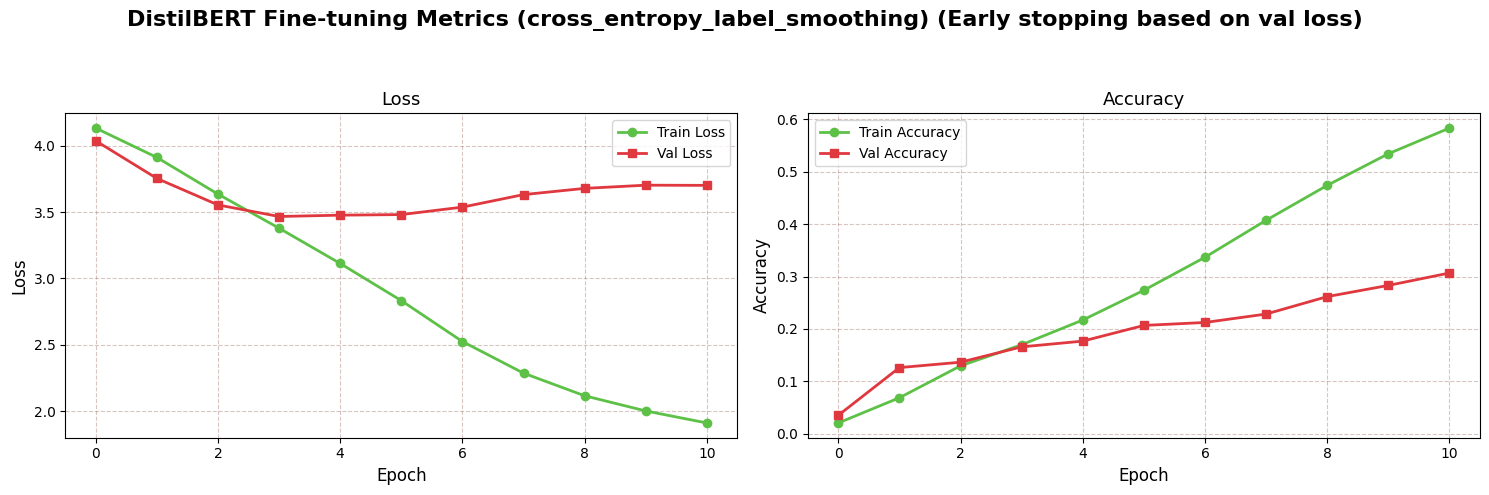

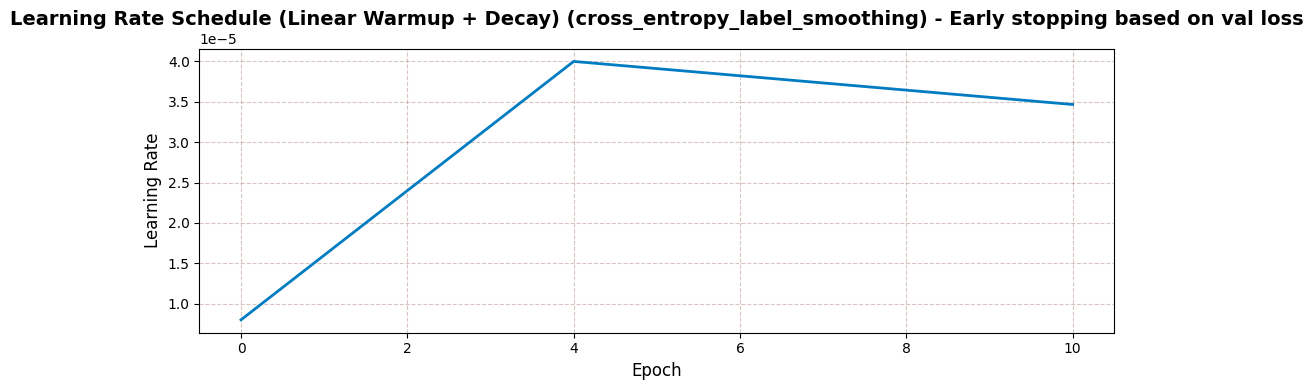


Per-class performance:
                    precision    recall  f1-score   support

           Cartman     0.5559    0.3550    0.4333      1428
              Stan     0.3812    0.3219    0.3490      1047
              Kyle     0.4327    0.1833    0.2575       982
           Butters     0.3085    0.3643    0.3341       387
             Randy     0.2507    0.2351    0.2427       387
      Mr. Garrison     0.2210    0.2500    0.2346       160
            Sharon     0.2768    0.3769    0.3192       130
              Chef     0.3053    0.3125    0.3089       128
             Kenny     0.9402    0.9735    0.9565       113
             Jimmy     0.3046    0.4554    0.3651       101
        Mr. Mackey     0.4706    0.4167    0.4420        96
            Gerald     0.0714    0.0842    0.0773        95
             Liane     0.3453    0.5517    0.4248        87
             Wendy     0.1218    0.2857    0.1708        84
             Jimbo     0.2621    0.3253    0.2903        83
            She

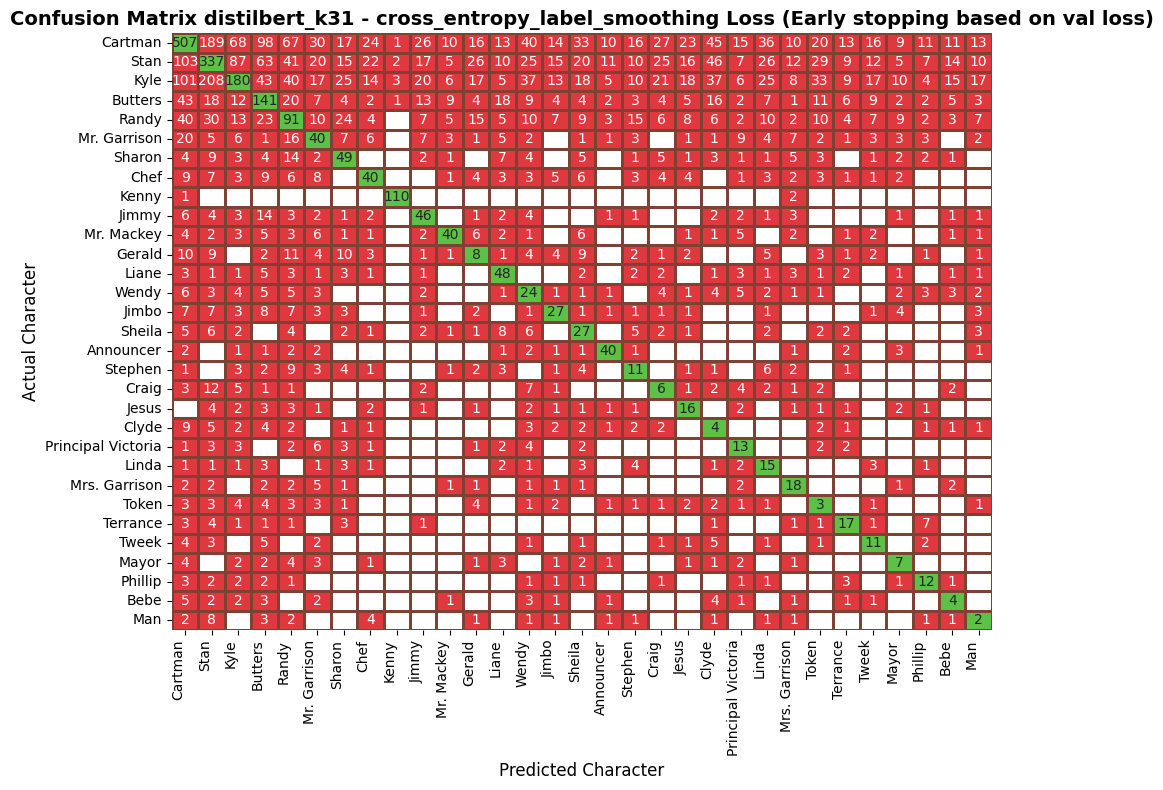

Evaluating: 100%|██████████| 95/95 [00:04<00:00, 21.25it/s]


DISTILBERT (PRE-TRAINED) - TEST SET PERFORMANCE
Accuracy:  0.3236
Precision: 0.2684
Recall:    0.2884
F1-Score:  0.2715


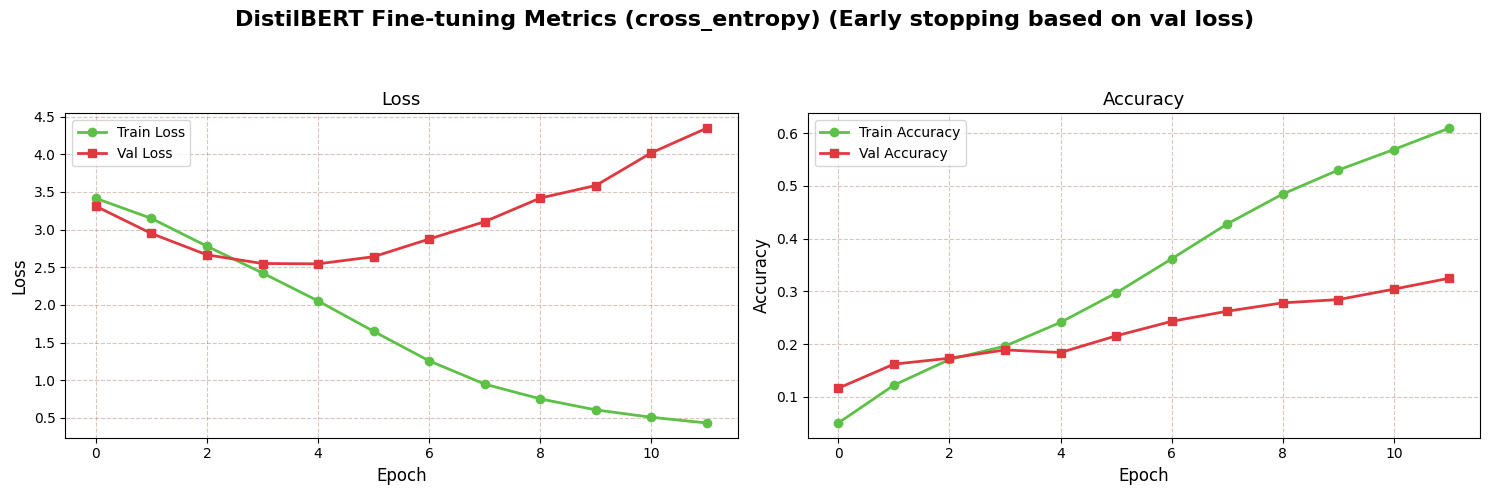

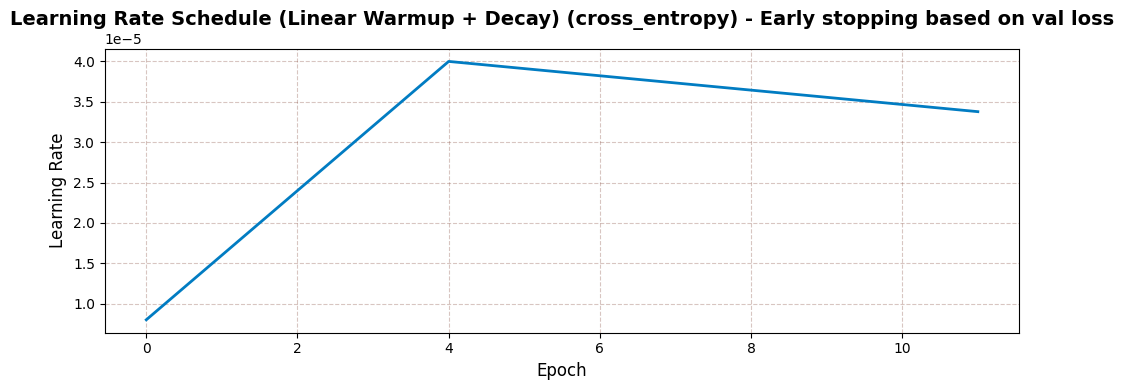


Per-class performance:
                    precision    recall  f1-score   support

           Cartman     0.5708    0.3557    0.4383      1428
              Stan     0.3687    0.2159    0.2723      1047
              Kyle     0.3195    0.3462    0.3324       982
           Butters     0.2874    0.4315    0.3450       387
             Randy     0.2177    0.3618    0.2718       387
      Mr. Garrison     0.2271    0.3250    0.2674       160
            Sharon     0.2113    0.3462    0.2624       130
              Chef     0.2923    0.2969    0.2946       128
             Kenny     0.9478    0.9646    0.9561       113
             Jimmy     0.4419    0.3762    0.4064       101
        Mr. Mackey     0.6066    0.3854    0.4713        96
            Gerald     0.0703    0.0947    0.0807        95
             Liane     0.4526    0.4943    0.4725        87
             Wendy     0.1085    0.1667    0.1315        84
             Jimbo     0.2245    0.2651    0.2431        83
            She

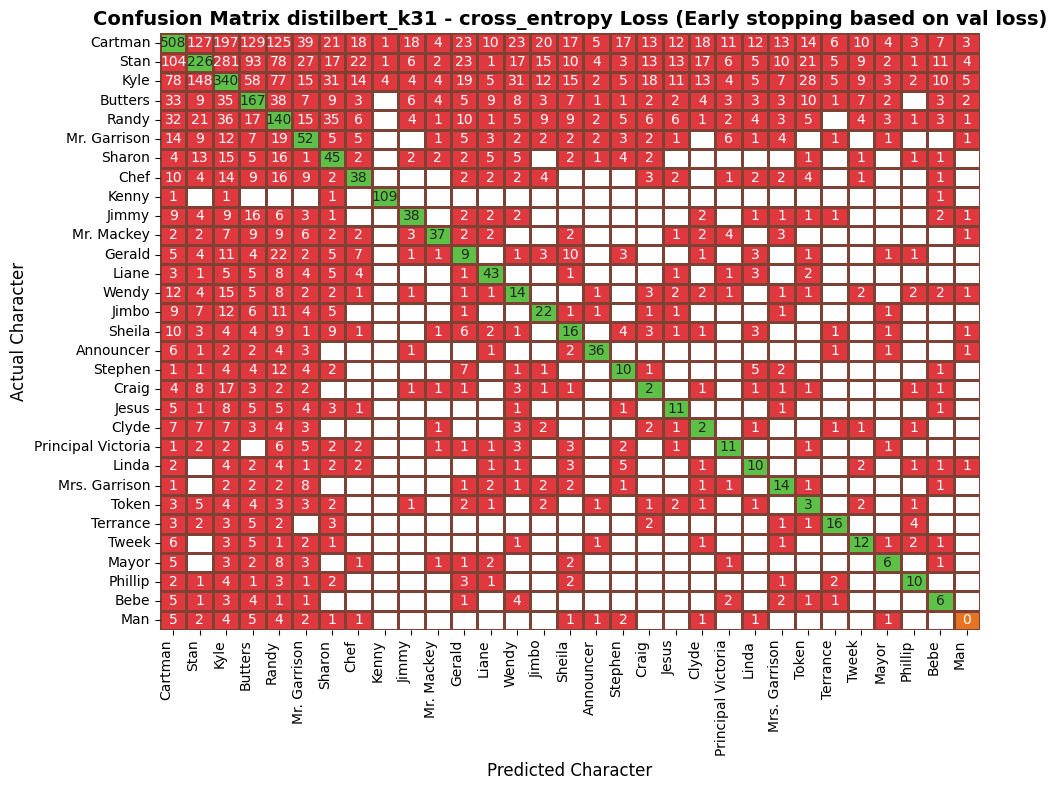

Evaluating: 100%|██████████| 95/95 [00:04<00:00, 21.19it/s]


DISTILBERT (PRE-TRAINED) - TEST SET PERFORMANCE
Accuracy:  0.3115
Precision: 0.2514
Recall:    0.2923
F1-Score:  0.2623


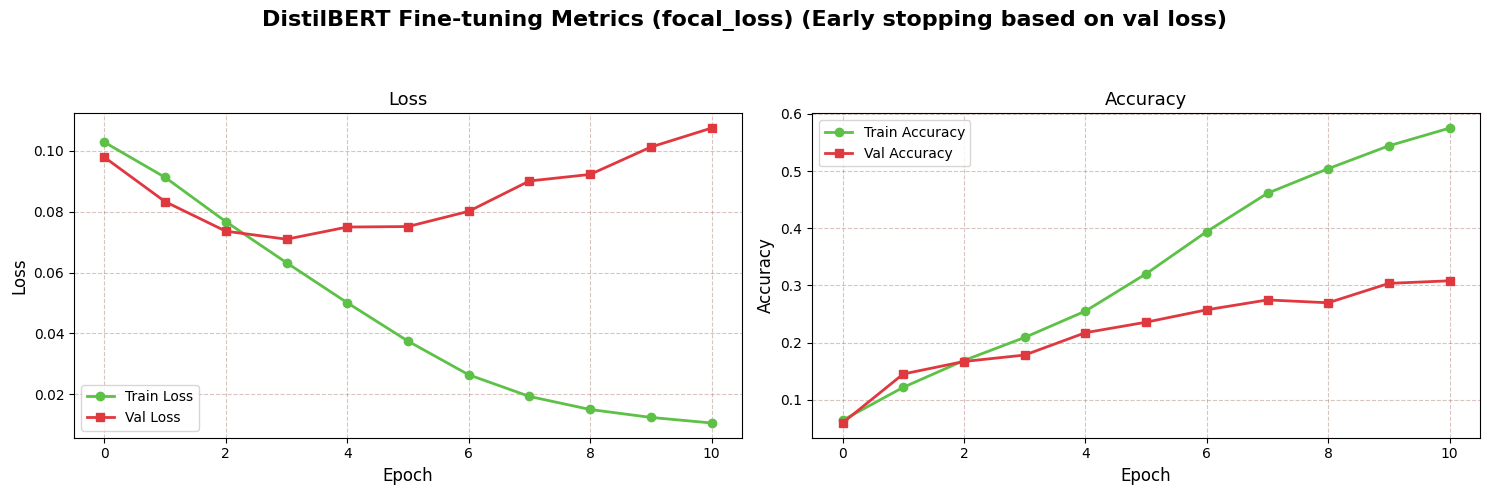

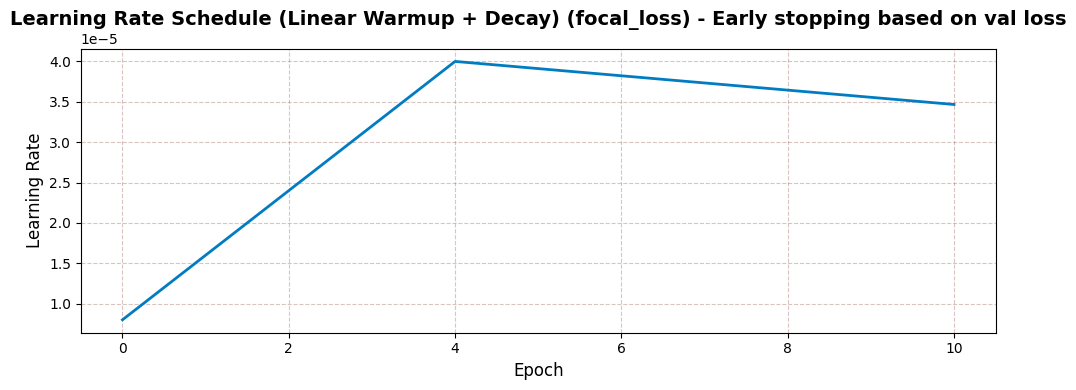


Per-class performance:
                    precision    recall  f1-score   support

           Cartman     0.5193    0.3585    0.4242      1428
              Stan     0.4260    0.2034    0.2754      1047
              Kyle     0.3706    0.2770    0.3170       982
           Butters     0.2556    0.3824    0.3064       387
             Randy     0.2054    0.3514    0.2593       387
      Mr. Garrison     0.1962    0.3250    0.2447       160
            Sharon     0.2381    0.3077    0.2685       130
              Chef     0.3333    0.3359    0.3346       128
             Kenny     0.9160    0.9646    0.9397       113
             Jimmy     0.2686    0.4653    0.3406       101
        Mr. Mackey     0.4643    0.4062    0.4333        96
            Gerald     0.1048    0.1158    0.1100        95
             Liane     0.4273    0.5402    0.4772        87
             Wendy     0.0803    0.2619    0.1229        84
             Jimbo     0.2947    0.3373    0.3146        83
            She

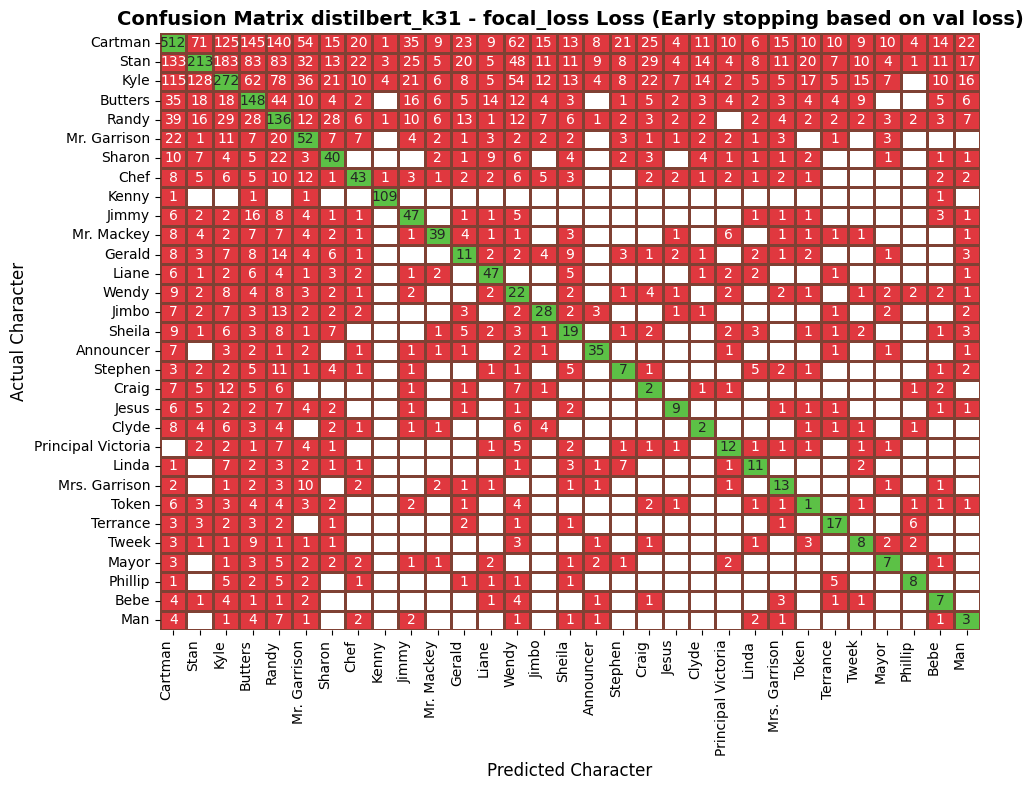

Evaluating: 100%|██████████| 95/95 [00:04<00:00, 21.14it/s]


In [48]:
from evaluate_models import COLOR_DICT, SP_BLUE, SP_ORANGE, SP_GREEN, SP_BROWN, SP_RED

def evaluate_distilbert(model, loader):
    """Evaluate DistilBERT model on a dataset."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_score': f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }

    return metrics, all_preds, all_labels

test_metrics_df = []

def plot_training_history(result, result_type):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"DistilBERT Fine-tuning Metrics ({result_type}) (Early stopping based on val loss)", fontsize=16, fontweight="bold")
    axes[0].plot(result['history']['train_loss'], label='Train Loss', marker='o', color=SP_GREEN, linewidth=2)
    axes[0].plot(result['history']['val_loss'], label='Val Loss', marker='s', color=SP_RED, linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss', fontsize=13)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, color=SP_BROWN, linestyle='--')

    axes[1].plot(result['history']['train_acc'], label='Train Accuracy', marker='o', color=SP_GREEN, linewidth=2)
    axes[1].plot(result['history']['val_acc'], label='Val Accuracy', marker='s', color=SP_RED, linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy', fontsize=13)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, color=SP_BROWN, linestyle='--')

   
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(f'distilbert_k{K}_training_history_{result_type}_val_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(result['history']['lr'], color=SP_BLUE, linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.title(f'Learning Rate Schedule (Linear Warmup + Decay) ({result_type}) - Early stopping based on val loss', fontweight='bold', fontsize=14)
    plt.grid(True, alpha=0.3, color=SP_BROWN, linestyle='--')
    plt.tight_layout()
    plt.savefig(f'distilbert_k{K}_lr_schedule_{result_type}_val_loss.png', dpi=150, bbox_inches='tight')
    plt.show()


best_val_loss = float('inf')
for loss_type, result in results.items():
    model = result['model']
    test_metrics, test_preds, test_labels_list = evaluate_distilbert(model, test_loader)
    y_true = [label_to_char[i] for i in test_labels_list]

    
    if best_val_loss > result['best_val_loss']:
        best_val_loss = result['best_val_loss']
        best_model = model
        best_loss_type = loss_type
        best_test_metrics = test_metrics
        best_test_preds = test_preds
        best_test_labels_list = test_labels_list

    print("=" * 80)
    print("DISTILBERT (PRE-TRAINED) - TEST SET PERFORMANCE")
    print("=" * 80)
    print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall:    {test_metrics['recall']:.4f}")
    print(f"F1-Score:  {test_metrics['f1_score']:.4f}")
    print("=" * 80)

    plot_training_history(result, loss_type)

    print("\nPer-class performance:")
    from sklearn.metrics import classification_report
    print(classification_report(
        test_labels_list,
        test_preds,
        target_names=[label_to_char[i] for i in range(K)],
        digits=4
    ))

    plot_confusion_matrix(
        y_true,
        [label_to_char[i] for i in test_preds],
        save_path=f'distilbert_k{K}_loss_{loss_type}_confusion_matrix_val_loss.png',
        title=f"Confusion Matrix distilbert_k{K} - {loss_type} Loss (Early stopping based on val loss)"
    )

    test_metrics_df.append(pd.DataFrame([test_metrics], index=[f'DistilBERT_{loss_type}_val_loss']))

test_metrics_df = pd.concat(test_metrics_df)
test_metrics, test_preds, test_labels_list = evaluate_distilbert(best_model, test_loader)

In [49]:
test_metrics_df

,accuracy,precision,recall,f1_score
DistilBERT_cross_entropy_label_smoothing_val_loss,0.313784,0.241547,0.315980,0.261654
DistilBERT_cross_entropy_val_loss,0.323559,0.268370,0.288440,0.271511
DistilBERT_focal_loss_val_loss,0.311465,0.251446,0.292268,0.262312


In [50]:
test_metrics_df.to_csv(f'distilbert_k{K}_test_metrics_val_loss.csv')

## 13. Save Model
Save the fine-tuned DistilBERT model with full configuration and metrics.

In [51]:
# Save checkpoint
results_best_loss_type = results[best_loss_type]
model = results_best_loss_type['model']
time = results_best_loss_type['time']
checkpoint = {
    'model_type': 'DistilBERT (Fine-tuned)',
    'model_state_dict': model.state_dict(),
    'config': {
        'K': K,
        'model_name': MODEL_NAME,
        'max_seq_len': MAX_SEQ_LEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'warmup_ratio': WARMUP_RATIO,
        'num_epochs': NUM_EPOCHS,
        'early_stop_patience': EARLY_STOP_PATIENCE
    },
    'char_to_label': char_to_label,
    'label_to_char': label_to_char,
    'test_metrics': test_metrics,
    'history': results_best_loss_type['history'],
    'training_time': time,
    'total_parameters': sum(p.numel() for p in model.parameters())
}

# Save model checkpoint
filename = f'distilbert_k{K}_val_loss.pt'
torch.save(checkpoint, filename)

# Also save the full model in Hugging Face format (optional)
model_dir = f'distilbert_south_park_k{K}_val_loss'
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

print(f"Model saved to: {filename}")
print(f"Hugging Face model saved to: {model_dir}/")

print(f"\nModel Summary:")
print(f"  Architecture: DistilBERT (Fine-tuned)")
print(f"  Base model: {MODEL_NAME}")
print(f"  Parameters: {checkpoint['total_parameters']:,}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Vocabulary size: {len(tokenizer):,}")

print(f"\nPerformance:")
print(f"  Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  Test Precision: {test_metrics['precision']:.4f}")
print(f"  Test Recall: {test_metrics['recall']:.4f}")
print(f"  Test F1-Score: {test_metrics['f1_score']:.4f}")
print(f"  Fine-tuning time: {time/60:.2f} minutes")


print(f"\nTo load this model later:")
print(f"  # Load from checkpoint")
print(f"  checkpoint = torch.load('{filename}')")
print(f"  model.load_state_dict(checkpoint['model_state_dict'])")
print(f"  ")
print(f"  # Or load from Hugging Face format")
print(f"  model = DistilBertForSequenceClassification.from_pretrained('{model_dir}')")
print(f"  tokenizer = DistilBertTokenizer.from_pretrained('{model_dir}')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: distilbert_k31_val_loss.pt
Hugging Face model saved to: distilbert_south_park_k31_val_loss/

Model Summary:
  Architecture: DistilBERT (Fine-tuned)
  Base model: distilbert-base-uncased
  Parameters: 66,977,311
  Max sequence length: 256
  Vocabulary size: 30,522

Performance:
  Test Accuracy: 0.3115
  Test Precision: 0.2514
  Test Recall: 0.2923
  Test F1-Score: 0.2623
  Fine-tuning time: 10.71 minutes

To load this model later:
  # Load from checkpoint
  checkpoint = torch.load('distilbert_k31_val_loss.pt')
  model.load_state_dict(checkpoint['model_state_dict'])
  
  # Or load from Hugging Face format
  model = DistilBertForSequenceClassification.from_pretrained('distilbert_south_park_k31_val_loss')
  tokenizer = DistilBertTokenizer.from_pretrained('distilbert_south_park_k31_val_loss')
